In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = np.load("/content/drive/MyDrive/Datasets/traffic_data.npz")

In [ ]:
x_arr = data['X']
y_arr = data['y']

In [ ]:
x_arr.shape

(106, 128, 128, 3)

In [ ]:
x_arr[0]

array([[[0.7372549 , 0.71372549, 0.78823529],
        [0.70588235, 0.70196078, 0.77647059],
        [0.74509804, 0.70980392, 0.78823529],
        ...,
        [0.76470588, 0.78039216, 0.8627451 ],
        [0.76862745, 0.78823529, 0.85882353],
        [0.74901961, 0.76862745, 0.85098039]],

       [[0.73333333, 0.70980392, 0.77647059],
        [0.74117647, 0.7254902 , 0.8       ],
        [0.74117647, 0.71764706, 0.79215686],
        ...,
        [0.76862745, 0.78039216, 0.8627451 ],
        [0.75686275, 0.76862745, 0.85098039],
        [0.76470588, 0.77647059, 0.85882353]],

       [[0.7372549 , 0.72156863, 0.79607843],
        [0.74509804, 0.72156863, 0.79607843],
        [0.71372549, 0.70588235, 0.78039216],
        ...,
        [0.76862745, 0.78039216, 0.8627451 ],
        [0.76470588, 0.78039216, 0.8627451 ],
        [0.77254902, 0.78039216, 0.85098039]],

       ...,

       [[0.69803922, 0.7254902 , 0.80392157],
        [0.70588235, 0.70980392, 0.78823529],
        [0.71372549, 0

In [ ]:
import matplotlib.pyplot as plt

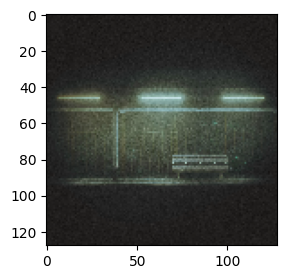

In [ ]:
plt.figure(figsize=(3, 3))
plt.imshow(x_arr[54])

In [ ]:
y_arr[54]

np.str_('bus_stop')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
y_arr_encoded = label_encoder.fit_transform(y_arr)

In [ ]:
from sklearn.utils import shuffle

x_arr, y_arr_encoded = shuffle(x_arr, y_arr_encoded, random_state=42)

In [ ]:
y_arr_encoded

array([1, 3, 3, 1, 1, 0, 2, 2, 1, 3, 0, 2, 3, 1, 2, 0, 0, 1, 0, 0, 3, 1,
       0, 2, 2, 2, 0, 1, 2, 1, 2, 1, 3, 0, 1, 2, 2, 3, 1, 1, 2, 2, 2, 0,
       2, 3, 0, 0, 0, 2, 2, 1, 1, 2, 0, 0, 2, 2, 3, 2, 2, 3, 1, 3, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 2, 0, 0, 1, 0, 1, 2, 1, 0, 0, 1, 2, 2,
       1, 3, 0, 2, 3, 2, 1, 1, 1, 1, 1, 2, 0, 0, 2, 1, 0, 1])

In [ ]:
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    x_arr, y_arr_encoded, test_size=0.2, random_state=42
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(X_train, y_train_encoded, epochs=6, validation_data=(X_test, y_test_encoded))

Epoch 1/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2738 - loss: 1.7223 - val_accuracy: 0.2727 - val_loss: 1.4528
Epoch 2/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 848ms/step - accuracy: 0.2619 - loss: 1.4629 - val_accuracy: 0.2727 - val_loss: 1.3380
Epoch 3/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 848ms/step - accuracy: 0.3690 - loss: 1.2944 - val_accuracy: 0.2727 - val_loss: 1.2449
Epoch 4/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 805ms/step - accuracy: 0.3810 - loss: 1.2321 - val_accuracy: 0.4091 - val_loss: 1.2590
Epoch 5/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5357 - loss: 1.1502 - val_accuracy: 0.4091 - val_loss: 1.2471
Epoch 6/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 850ms/step - accuracy: 0.5357 - loss: 1.0922 - val_accuracy: 0.2727 - val_loss: 1.1696


In [ ]:
model.evaluate(X_test, y_test_encoded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.2727 - loss: 1.1696


[1.1696357727050781, 0.27272728085517883]

In [ ]:
model_ag = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)), # Explicit Input layer

    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation='softmax')
])

model_ag.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
model_ag.fit(X_train, y_train_encoded, epochs=20, validation_data=(X_test, y_test_encoded), callbacks = [early_stop])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2857 - loss: 1.4204 - val_accuracy: 0.4091 - val_loss: 1.2311
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2857 - loss: 1.3771 - val_accuracy: 0.2727 - val_loss: 1.3145
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 886ms/step - accuracy: 0.3452 - loss: 1.3335 - val_accuracy: 0.2727 - val_loss: 1.2909
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 876ms/step - accuracy: 0.3095 - loss: 1.3740 - val_accuracy: 0.4091 - val_loss: 1.2586


In [ ]:
model_ag.evaluate(X_test, y_test_encoded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4091 - loss: 1.2311


[1.2310771942138672, 0.40909090638160706]

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

baseline_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

for layer in baseline_model.layers:
    layer.trainable = False

model_tl = tf.keras.Sequential([
    baseline_model,
    GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

In [ ]:
model_tl.fit(X_test,y_test_encoded,epochs=20, validation_data=(X_test, y_test_encoded), callbacks = [early_stop])

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.1818 - loss: 2.7820 - val_accuracy: 0.5909 - val_loss: 0.8992
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step - accuracy: 0.4545 - loss: 1.2129 - val_accuracy: 0.8636 - val_loss: 0.5237
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step - accuracy: 0.6818 - loss: 0.9260 - val_accuracy: 0.9091 - val_loss: 0.2989
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step - accuracy: 0.6818 - loss: 0.8548 - val_accuracy: 0.9545 - val_loss: 0.1596
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step - accuracy: 0.8636 - loss: 0.3154 - val_accuracy: 1.0000 - val_loss: 0.0865
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step - accuracy: 0.9091 - loss: 0.3167 - val_accuracy: 1.0000 - val_loss: 0.0458
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step - accuracy: 1.0000 - loss: 0.0882 - val_accuracy: 1.0000 - val_loss: 0.0268
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step - accuracy: 1.0000 - loss: 0.0675 - val_accuracy: 1.0000 - val_loss: 0.

In [ ]:
model_tl.evaluate(X_test, y_test_encoded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 1.0000 - loss: 8.2814e-04


[0.0008281408227048814, 1.0]

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1
accuracies = []

for train_index, val_index in kf.split(X_train):
    print(f"\n----- Fold {fold_no} -----")
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train_encoded[train_index], y_train_encoded[val_index]

    baseline_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
    for layer in baseline_model.layers:
        layer.trainable = False

    model_tl = tf.keras.Sequential([
        baseline_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    model_tl.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

    model_tl.fit(X_train_fold, y_train_fold, epochs=10, validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)

    _, accuracy = model_tl.evaluate(X_val_fold, y_val_fold, verbose=0)
    accuracies.append(accuracy)
    print(f"Fold {fold_no} Validation Accuracy: {accuracy:.4f}")
    fold_no += 1

print(f"\nAverage Cross-Validation Accuracy: {np.mean(accuracies):.4f}")
print(f"Standard Deviation of Cross-Validation Accuracy: {np.std(accuracies):.4f}")


----- Fold 1 -----
Fold 1 Validation Accuracy: 0.2353

----- Fold 2 -----
Fold 2 Validation Accuracy: 0.4118

----- Fold 3 -----
Fold 3 Validation Accuracy: 0.5294

----- Fold 4 -----
Fold 4 Validation Accuracy: 0.4118

----- Fold 5 -----
Fold 5 Validation Accuracy: 0.5625

Average Cross-Validation Accuracy: 0.4301
Standard Deviation of Cross-Validation Accuracy: 0.1149
